In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn jupyter

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached notebook_shim-0.2.4-py3-none-any.whl.metadata (4.0 kB)
  Using cached argon2_cffi-25.1.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached terminado-0.18.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached websocket_client-1.9.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached rfc3339_validator-0.1.4-py2.py3-none-any.whl.metadata (1.5 kB)
  Using cached rfc3986_validator-0.1.1-py2.py3-none-any.whl.metadata (1.7 kB)
  Using 


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ecommerce_500k.csv")
df.head()

Matplotlib is building the font cache; this may take a moment.


,order_id,customer_id,product_id,order_date,category,sub_category,product_base_price,discount_percentage,final_price,quantity,...,city,loyalty_tier,is_first_purchase,customer_lifetime_value,session_duration_mins,pages_viewed,clicks_to_purchase,is_returned,return_reason,is_cancelled
0,1000001,25795,90,2022-07-31,Clothing,Men,70.41,25,52.81,1,...,Bangalore,Bronze,0,457.77,4.6,35.0,7,0,NaN,0
1,1000002,10860,1917,2023-09-25,Automotive,Car Care,6.02,10,5.42,3,...,Toronto,Bronze,0,1606.42,2.9,8.0,8,0,NaN,0
2,1000003,86820,805,2022-03-26,Books,Textbooks,78.85,20,63.08,2,...,Chicago,Silver,0,252.16,5.5,38.0,8,0,NaN,0
3,1000004,64886,3379,2022-11-03,Books,Non-Fiction,58.42,25,43.82,4,...,Sydney,Bronze,0,645.12,6.1,30.0,9,0,NaN,0
4,1000005,16265,4604,2022-06-30,Clothing,Women,73.38,15,62.37,1,...,Manchester,Bronze,1,1103.24,1.6,38.0,11,0,NaN,0


In [4]:
df.shape

(500000, 30)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   order_id                 500000 non-null  int64  
 1   customer_id              500000 non-null  int64  
 2   product_id               500000 non-null  int64  
 3   order_date               500000 non-null  str    
 4   category                 500000 non-null  str    
 5   sub_category             500000 non-null  str    
 6   product_base_price       500000 non-null  float64
 7   discount_percentage      500000 non-null  int64  
 8   final_price              500000 non-null  float64
 9   quantity                 500000 non-null  int64  
 10  total_amount             500000 non-null  float64
 11  shipping_cost            484934 non-null  float64
 12  shipping_method          500000 non-null  str    
 13  days_to_deliver          484751 non-null  float64
 14  payment_method 

In [6]:
df.isnull().sum()

order_id                        0
customer_id                     0
product_id                      0
order_date                      0
category                        0
sub_category                    0
product_base_price              0
discount_percentage             0
final_price                     0
quantity                        0
total_amount                    0
shipping_cost               15066
shipping_method                 0
days_to_deliver             15249
payment_method                  0
rating                      14990
num_reviews                     0
customer_age                14928
customer_gender                 0
country                         0
city                            0
loyalty_tier                    0
is_first_purchase               0
customer_lifetime_value     15004
session_duration_mins       14725
pages_viewed                14814
clicks_to_purchase              0
is_returned                     0
return_reason              440096
is_cancelled  

In [7]:
df.describe()

,order_id,customer_id,product_id,product_base_price,discount_percentage,final_price,quantity,total_amount,shipping_cost,days_to_deliver,rating,num_reviews,customer_age,is_first_purchase,customer_lifetime_value,session_duration_mins,pages_viewed,clicks_to_purchase,is_returned,is_cancelled
count,5.000000e+05,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,484934.000000,484751.000000,485010.000000,500000.000000,485072.000000,500000.000000,484996.000000,485275.000000,485186.000000,500000.000000,500000.000000,500000.000000
mean,1.250000e+06,55007.627196,2503.810058,84.833241,14.599090,72.438608,2.284080,165.605507,34.031570,4.238345,3.796253,27.015930,34.953966,0.278630,850.516871,8.511644,25.054783,9.999486,0.119808,0.061662
std,1.443377e+05,25995.094710,1441.201322,79.984198,12.943309,69.900582,1.739378,237.412198,39.185919,2.398417,0.943732,16.425337,11.132444,0.448325,799.762647,8.035044,14.142187,5.475479,0.324737,0.240541
min,1.000001e+06,10000.000000,1.000000,5.000000,0.000000,2.500000,1.000000,2.500000,0.000000,1.000000,1.000000,0.000000,18.000000,0.000000,50.000000,0.500000,1.000000,1.000000,0.000000,0.000000
25%,1.125001e+06,32490.000000,1259.000000,28.040000,0.000000,23.440000,1.000000,37.710000,4.540000,3.000000,3.500000,15.000000,26.000000,0.000000,280.180000,2.800000,13.000000,5.000000,0.000000,0.000000
50%,1.250000e+06,55056.500000,2503.000000,60.220000,15.000000,50.590000,2.000000,87.700000,24.890000,4.000000,4.000000,24.000000,35.000000,0.000000,604.170000,6.100000,25.000000,10.000000,0.000000,0.000000
75%,1.375000e+06,77510.000000,3752.000000,115.580000,20.000000,98.110000,3.000000,194.070000,44.020000,5.000000,4.500000,36.000000,43.000000,1.000000,1160.032500,11.600000,37.000000,15.000000,0.000000,0.000000
max,1.500000e+06,99998.000000,5000.000000,1148.770000,50.000000,1091.330000,10.000000,6617.300000,200.000000,14.000000,5.000000,166.000000,80.000000,1.000000,11606.040000,121.400000,49.000000,19.000000,1.000000,1.000000


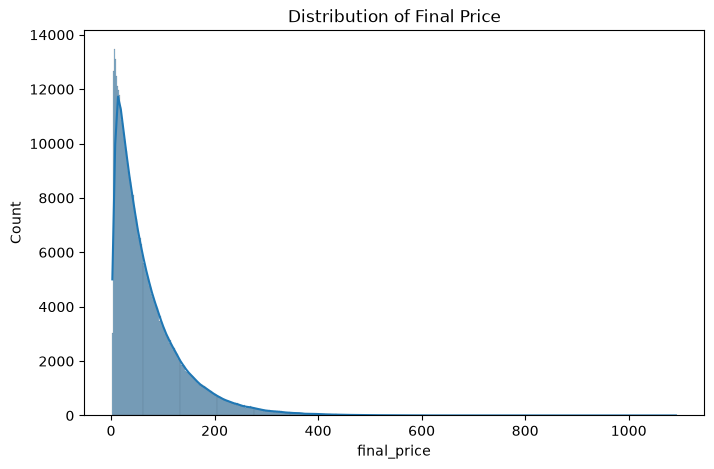

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['final_price'], kde=True)
plt.title("Distribution of Final Price")
plt.show()

In [10]:
df['final_price'].skew()

np.float64(2.1078088185916877)

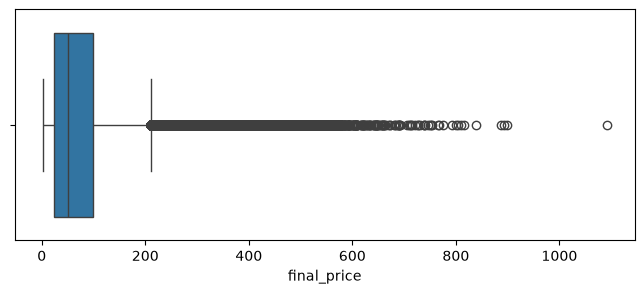

In [11]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df['final_price'])
plt.show()

In [12]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

C:\Users\aashi\AppData\Local\Temp\ipykernel_29976\910776789.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


Index(['order_date', 'category', 'sub_category', 'shipping_method',
       'payment_method', 'customer_gender', 'country', 'city', 'loyalty_tier',
       'return_reason'],
      dtype='str')

In [13]:
for col in cat_cols:
    print(col, ":", df[col].nunique())

order_date : 1095
category : 10
sub_category : 45
shipping_method : 4
payment_method : 6
customer_gender : 3
country : 8
city : 15
loyalty_tier : 4
return_reason : 5


In [14]:
df['is_returned'].value_counts(normalize=True)*100

is_returned
0    88.0192
1    11.9808
Name: proportion, dtype: float64

In [15]:
pd.crosstab(
    df['category'],
    df['is_returned'],
    normalize='index'
)

is_returned,0,1
category,,
Automotive,0.879525,0.120475
Beauty,0.879429,0.120571
Books,0.879580,0.120420
Clothing,0.881809,0.118191
Electronics,0.878861,0.121139
Food & Grocery,0.880677,0.119323
Furniture,0.879017,0.120983
Home & Kitchen,0.881053,0.118947
Sports,0.881357,0.118643


In [16]:
pd.crosstab(
    df['loyalty_tier'],
    df['is_returned'],
    normalize='index'
)

is_returned,0,1
loyalty_tier,,
Bronze,0.879713,0.120287
Gold,0.880172,0.119828
Platinum,0.880402,0.119598
Silver,0.880866,0.119134


In [17]:
df.groupby('is_returned')['days_to_deliver'].mean()

is_returned
0    4.237801
1    4.242337
Name: days_to_deliver, dtype: float64

In [18]:
df.groupby('is_returned')['rating'].mean()

is_returned
0    3.797806
1    3.784849
Name: rating, dtype: float64

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [20]:
num_cols = [
    'product_base_price',
    'final_price',
    'quantity',
    'shipping_cost',
    'days_to_deliver',
    'rating',
    'customer_age',
    'customer_lifetime_value'
]

In [21]:
cat_cols = [
    'category',
    'sub_category',
    'shipping_method',
    'payment_method',
    'customer_gender',
    'country',
    'city',
    'loyalty_tier'
]

In [22]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [23]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [24]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

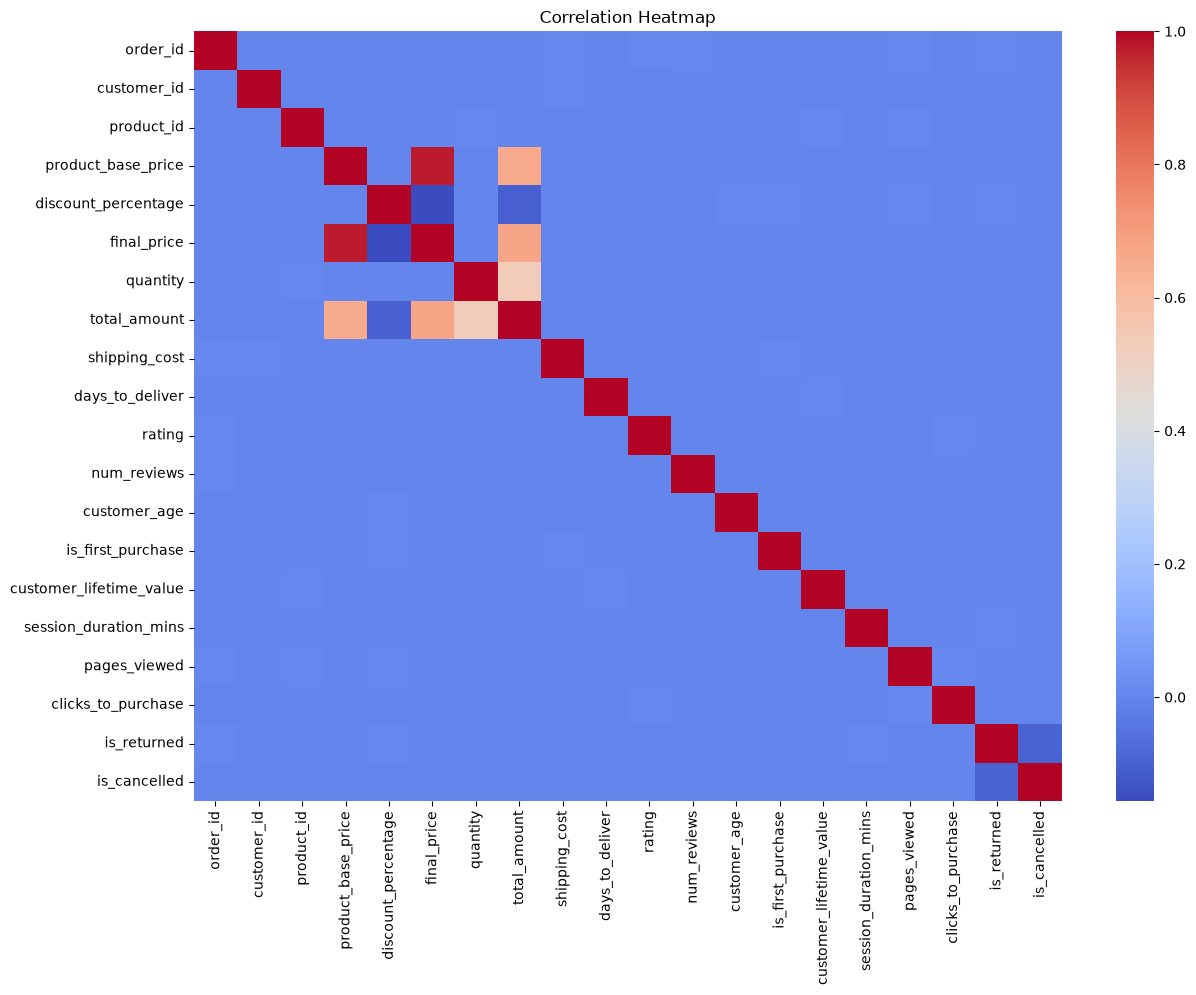

In [25]:
num_df = df.select_dtypes(include=np.number)

corr_matrix = num_df.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [26]:
corr_matrix['is_returned'].sort_values(ascending=False)

is_returned                1.000000
discount_percentage        0.002670
order_id                   0.002068
session_duration_mins      0.002037
pages_viewed               0.001297
is_first_purchase          0.001002
days_to_deliver            0.000614
customer_lifetime_value    0.000235
quantity                  -0.000420
customer_age              -0.000679
num_reviews               -0.000858
clicks_to_purchase        -0.000995
customer_id               -0.001203
shipping_cost             -0.001265
product_base_price        -0.001294
product_id                -0.001383
total_amount              -0.001512
final_price               -0.001599
rating                    -0.004459
is_cancelled              -0.094577
Name: is_returned, dtype: float64